# Phishing URL Detection — Model 2: Character-Level BiLSTM

## Context
This notebook implements a second model for phishing URL detection to complement the Random Forest baseline (`analyis.ipynb`). The same two datasets are used:
- **Primary dataset** (Mendeley): 54,807 phishing + legitimate URLs
- **Secondary dataset** (Kaggle): 651,191 URLs (benign / phishing / malware / defacement)

---

## Model Rationale

### Why a Character-Level BiLSTM?

| Aspect | Random Forest (Model 1) | BiLSTM (Model 2) |
|---|---|---|
| **Input representation** | TF-IDF char n-grams (bag-of-n-grams, no order) + handcrafted stats | Raw character sequence — order preserved |
| **Sequential structure** | Ignored | Explicitly modeled by LSTM hidden state |
| **Long-range patterns** | Lost after vectorization | Captured via bidirectional passes |
| **Generalization** | Can overfit to n-gram vocabulary of training set | Character embeddings learned end-to-end, more transferable |
| **Interpretability** | High (feature importances) | Lower (attention weights partially help) |
| **Training cost** | Low | Moderate (GPU optional but helpful) |

**Strengths of BiLSTM for URLs:**
- Phishing URLs embed deceptive patterns in sub-sequences (e.g., `paypal-secure`, `login@`, IP addresses). A BiLSTM reading left-to-right *and* right-to-left captures these in context.
- Character embeddings generalise better across unseen domains because the model learns character-level semantics rather than relying on a fixed n-gram vocabulary.
- No manual feature engineering — the network discovers discriminative patterns itself.

**Potential pitfalls:**
- Requires more data and tuning than a Random Forest.
- URLs can be very long; we truncate/pad to a fixed length, potentially losing tail information.
- Training is slower and less interpretable.
- Can still overfit if the character vocabulary distribution differs between datasets.


## 1. Imports & Configuration

In [4]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"Using device: {DEVICE}")

# Hyperparameters — centralised for easy tuning
MAX_LEN = 100  # truncate/pad URLs to this many characters
EMBED_DIM = 64  # character embedding size
HIDDEN_DIM = 64  # LSTM hidden units per direction (1 layer is much faster on CPU)
NUM_LAYERS = 1  # stacked LSTM layers
DROPOUT = 0.3
BATCH_SIZE = 1024
EPOCHS = 8
LR = 1e-3
SUBSAMPLE_N = (
    100_000  # rows sampled from primary dataset — set to None to use all ~500k
)

Using device: mps


## 2. Data Loading & Preparation

Replicates the same dataset preparation as the Random Forest notebook so both models are evaluated on identical splits.

In [5]:
# --- Load datasets ---
phish_df = pd.read_csv("Phishing URLs.csv")
phish_df = phish_df.rename(columns={"Type": "type"})
phish_df["type"] = phish_df["type"].str.lower()

real_df = pd.read_csv("URL dataset.csv")
real_df["type"] = "benign"  # Mark all URLs from this dataset as benign/legitimate

kaggle_df = pd.read_csv("kaggle_dataset.csv")
# Check columns and standardize the label column
print("Kaggle columns:", kaggle_df.columns.tolist())
# Rename label column to 'type' if it exists (adjust column name as needed)
if "label" in kaggle_df.columns:
    kaggle_df = kaggle_df.rename(columns={"label": "type"})
if "type" in kaggle_df.columns:
    kaggle_df["type"] = kaggle_df["type"].str.lower()

# --- Build primary training corpus ---
prim_df = pd.concat([phish_df, real_df], ignore_index=True)
prim_df.loc[prim_df["type"] == "legitimate", "type"] = "benign"
prim_df = prim_df[["url", "type"]].dropna()

Kaggle columns: ['url', 'type']


## 3. Character-Level Vocabulary & Tokenizer

We map each character to an integer index. The vocabulary is built from the training set only to prevent leakage. Unknown characters (OOV) map to a special `<UNK>` token; padding uses `<PAD>`.

In [6]:
# --- Train/test split (same random state as RF notebook) ---
X = prim_df["url"]
y = (prim_df["type"] == "phishing").astype(int)  # 1 = phishing, 0 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")

# --- Build char vocabulary from training URLs only ---
PAD_TOKEN = "<PAD>"  # index 0
UNK_TOKEN = "<UNK>"  # index 1

all_chars = set()
for url in X_train:
    all_chars.update(url)

char2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for ch in sorted(all_chars):
    char2idx[ch] = len(char2idx)

VOCAB_SIZE = len(char2idx)
print(f"Vocabulary size: {VOCAB_SIZE} unique characters")


def tokenize(url: str, max_len: int = MAX_LEN) -> list[int]:
    """Convert URL string to a fixed-length integer sequence."""
    tokens = [char2idx.get(ch, 1) for ch in url[:max_len]]  # truncate
    tokens += [0] * (max_len - len(tokens))  # pad
    return tokens


# Sanity check
sample = X_train.iloc[0]
print(f"\nSample URL: {sample[:60]}")
print(f"Tokenized (first 20): {tokenize(sample)[:20]}")

Train size: 403,986  |  Test size: 100,997
Vocabulary size: 170 unique characters

Sample URL: https://www.gazprombank.ru/eng/research/team/
Tokenized (first 20): [76, 88, 88, 84, 87, 30, 19, 19, 91, 91, 91, 18, 75, 69, 94, 84, 86, 83, 81, 70]


## 4. PyTorch Dataset & DataLoader

In [7]:
class URLDataset(Dataset):
    def __init__(self, urls: pd.Series, labels: pd.Series):
        self.tokens = torch.tensor([tokenize(u) for u in urls], dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tokens[idx], self.labels[idx]


print("Building datasets (this may take ~30s for the full corpus)...")
t0 = time.time()
train_dataset = URLDataset(X_train, y_train)
test_dataset = URLDataset(X_test, y_test)
print(f"Done in {time.time()-t0:.1f}s")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f"\nTrain batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Building datasets (this may take ~30s for the full corpus)...
Done in 3.1s

Train batches: 395  |  Test batches: 99


## 5. Model Architecture

```
Input URL  (batch, MAX_LEN)  — integer character indices
      ↓
Embedding  (batch, MAX_LEN, EMBED_DIM)
      ↓
Bidirectional LSTM ×2 layers  (batch, MAX_LEN, 2*HIDDEN_DIM)
      ↓  mean-pool over time dimension
Dense (2*HIDDEN_DIM → 64) + ReLU + Dropout
      ↓
Dense (64 → 1) + Sigmoid  →  P(phishing)
```

**Design choices:**
- **Bidirectional**: captures both prefix cues (e.g., `http://192.`) and suffix cues (e.g., `.exe`, `.php?id=`).
- **Mean pooling**: more stable than taking just the final hidden state for variable-length URLs because all positions contribute equally.
- **2 LSTM layers**: allows the model to learn hierarchical sequential features (character combos → sub-word patterns).
- **Dropout 0.4**: regularises the large hidden state to reduce overfitting.

In [8]:
class PhishingBiLSTM(nn.Module):
    """
    Character-level Bidirectional LSTM for phishing URL detection.

    Architecture:
        Embedding → BiLSTM (num_layers) → mean-pool → FC → sigmoid
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = EMBED_DIM,
        hidden_dim: int = HIDDEN_DIM,
        num_layers: int = NUM_LAYERS,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0,  # PAD token — zero grad, ignored in mean
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)  # *2 for bidirectional
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(emb)  # (batch, seq_len, 2*hidden_dim)

        # Mean-pool over non-padding positions
        mask = (x != 0).unsqueeze(-1).float()  # (batch, seq_len, 1)
        pooled = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        out = self.dropout(F.relu(self.fc1(pooled)))
        out = torch.sigmoid(self.fc2(out)).squeeze(-1)  # (batch,)
        return out


model = PhishingBiLSTM(vocab_size=VOCAB_SIZE).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

PhishingBiLSTM(
  (embedding): Embedding(170, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 85,761


## 6. Training

**Loss**: Binary Cross-Entropy with class weighting to handle the 68/32 benign/phishing imbalance — mirrors the `class_weight='balanced'` used in the Random Forest.

**Optimizer**: Adam with an initial LR of 1e-3.

**Scheduler**: `ReduceLROnPlateau` — halves the LR if validation loss does not improve for 2 epochs, helping the model converge without manual tuning.

In [9]:
# Compute positive class weight for BCELoss (n_neg / n_pos)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(
    f"Positive (phishing) weight: {pos_weight.item():.3f}  (n_neg={n_neg:,}, n_pos={n_pos:,})"
)

criterion = nn.BCELoss(
    weight=None
)  # we apply pos_weight manually via BCEWithLogitsLoss alternative below
# Use weighted BCE: loss = -[w * y*log(p) + (1-y)*log(1-p)]
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# NOTE: because criterion is BCEWithLogitsLoss we skip the sigmoid in the forward pass output
# and redefine the model to return logits instead


class PhishingBiLSTM(nn.Module):
    """Same architecture but outputs raw logits for BCEWithLogitsLoss."""

    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        out = self.dropout(F.relu(self.fc1(pooled)))
        return self.fc2(out).squeeze(-1)  # raw logit


model = PhishingBiLSTM(VOCAB_SIZE).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

Positive (phishing) weight: 8.214  (n_neg=360,140, n_pos=43,846)


In [10]:
def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for tokens, labels in loader:
            tokens, labels = tokens.to(DEVICE), labels.to(DEVICE)
            logits = model(tokens)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(
    f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}"
)
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(test_loader, train=False)
    scheduler.step(v_loss)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"{epoch:>5}  {t_loss:>10.4f}  {t_acc:>9.4f}  {v_loss:>8.4f}  {v_acc:>7.4f}  {lr_now:>8.2e}"
    )

Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR
------------------------------------------------------------


/opt/miniconda3/envs/geo/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


    1      0.3767     0.9380    0.2296   0.9673  1.00e-03
    2      0.2252     0.9683    0.1988   0.9675  1.00e-03
    3      0.1878     0.9747    0.1761   0.9750  1.00e-03
    4      0.1679     0.9763    0.1642   0.9762  1.00e-03
    5      0.1546     0.9774    0.1543   0.9746  1.00e-03
    6      0.1456     0.9774    0.1495   0.9754  1.00e-03
    7      0.1333     0.9783    0.1440   0.9762  1.00e-03
    8      0.1237     0.9789    0.1405   0.9791  1.00e-03


## 7. Training Curves

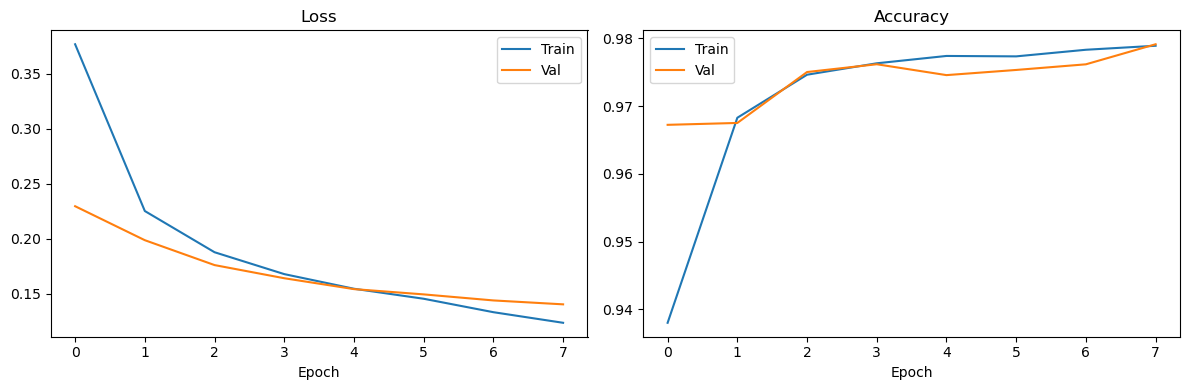

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("bilstm_training_curves.png", dpi=150)
plt.show()

## 8. Primary Dataset Evaluation

In [12]:
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for tokens, labels in test_loader:
        tokens = tokens.to(DEVICE)
        logits = model(tokens).cpu()
        all_logits.append(logits)
        all_labels.append(labels)

all_logits = torch.cat(all_logits).numpy()
all_labels = torch.cat(all_labels).numpy()

y_proba = torch.sigmoid(torch.tensor(all_logits)).numpy()
y_pred = (y_proba >= 0.5).astype(int)

label_names = ["benign", "phishing"]

print("=" * 55)
print("BiLSTM — PRIMARY DATASET PERFORMANCE")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(all_labels, y_pred):.4f}")
print(f"Precision: {precision_score(all_labels, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(all_labels, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(all_labels, y_pred, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(all_labels, y_proba):.4f}")
print()
print(classification_report(all_labels, y_pred, target_names=label_names))

# False negative rate
fn = ((all_labels == 1) & (y_pred == 0)).sum()
tp = ((all_labels == 1) & (y_pred == 1)).sum()
total_phish = (all_labels == 1).sum()
print(f"Phishing URLs missed (FN): {fn} / {total_phish}  ({fn/total_phish*100:.2f}%)")

BiLSTM — PRIMARY DATASET PERFORMANCE
Accuracy:  0.9791
Precision: 0.9811
Recall:    0.9791
F1-Score:  0.9797
ROC-AUC:   0.9956

              precision    recall  f1-score   support

      benign       1.00      0.98      0.99     90036
    phishing       0.86      0.97      0.91     10961

    accuracy                           0.98    100997
   macro avg       0.93      0.97      0.95    100997
weighted avg       0.98      0.98      0.98    100997

Phishing URLs missed (FN): 337 / 10961  (3.07%)


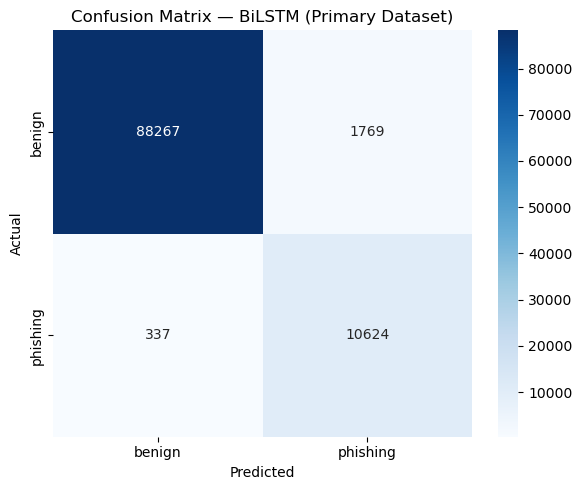

In [13]:
cm = confusion_matrix(all_labels, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — BiLSTM (Primary Dataset)")
plt.tight_layout()
plt.savefig("bilstm_confusion_matrix.png", dpi=150)
plt.show()

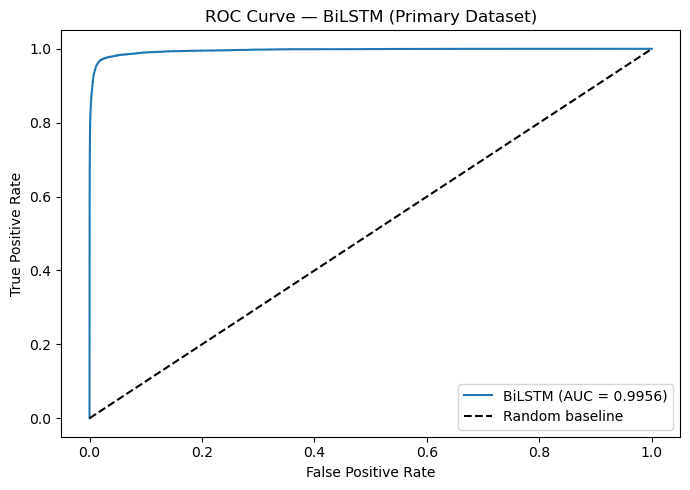

In [14]:
fpr, tpr, _ = roc_curve(all_labels, y_proba)
auc_score = roc_auc_score(all_labels, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"BiLSTM (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BiLSTM (Primary Dataset)")
plt.legend()
plt.tight_layout()
plt.savefig("bilstm_roc_curve.png", dpi=150)
plt.show()

## 9. Generalisation Test — Kaggle Dataset

The Random Forest model collapsed on this dataset (predicting ~97% phishing when only 18% were phishing). We test whether the BiLSTM generalises better.

In [16]:
kaggle_df = pd.read_csv("kaggle_dataset.csv")
kaggle_eval = kaggle_df[kaggle_df["type"].isin(["benign", "phishing"])]
print(f"Kaggle eval size: {len(kaggle_eval):,}")
print(kaggle_eval["type"].value_counts())

y_kaggle_true = (kaggle_eval["type"] == "phishing").astype(int)

# Tokenize
kaggle_tokens = torch.tensor(
    [tokenize(u) for u in kaggle_eval["url"]], dtype=torch.long
)
kaggle_dataset = torch.utils.data.TensorDataset(kaggle_tokens)
kaggle_loader = DataLoader(kaggle_dataset, batch_size=BATCH_SIZE)

model.eval()
kaggle_logits = []
with torch.no_grad():
    for (batch_tokens,) in kaggle_loader:
        batch_tokens = batch_tokens.to(DEVICE)
        kaggle_logits.append(model(batch_tokens).cpu())

kaggle_proba = torch.sigmoid(torch.cat(kaggle_logits)).numpy()
kaggle_pred = (kaggle_proba >= 0.5).astype(int)

print("\n" + "=" * 55)
print("BiLSTM — KAGGLE DATASET GENERALISATION")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_kaggle_true, kaggle_pred):.4f}")
print(
    f"Precision: {precision_score(y_kaggle_true, kaggle_pred, average='weighted', zero_division=0):.4f}"
)
print(
    f"Recall:    {recall_score(y_kaggle_true, kaggle_pred, average='weighted', zero_division=0):.4f}"
)
print(
    f"F1-Score:  {f1_score(y_kaggle_true, kaggle_pred, average='weighted', zero_division=0):.4f}"
)
print()
print(
    classification_report(
        y_kaggle_true, kaggle_pred, target_names=label_names, zero_division=0
    )
)

print("\nPredicted distribution:")
print(
    pd.Series(kaggle_pred)
    .map({0: "benign", 1: "phishing"})
    .value_counts(normalize=True)
)
print("\nActual distribution:")
print(kaggle_eval["type"].value_counts(normalize=True))

Kaggle eval size: 522,214
type
benign      428103
phishing     94111
Name: count, dtype: int64

BiLSTM — KAGGLE DATASET GENERALISATION
Accuracy:  0.7994
Precision: 0.7757
Recall:    0.7994
F1-Score:  0.7848

              precision    recall  f1-score   support

      benign       0.85      0.91      0.88    428103
    phishing       0.42      0.29      0.34     94111

    accuracy                           0.80    522214
   macro avg       0.64      0.60      0.61    522214
weighted avg       0.78      0.80      0.78    522214


Predicted distribution:
benign      0.874163
phishing    0.125837
Name: proportion, dtype: float64

Actual distribution:
type
benign      0.819785
phishing    0.180215
Name: proportion, dtype: float64


## 10. Model Comparison: Random Forest vs BiLSTM

We summarise the key numbers from both notebooks side-by-side.

In [17]:
comparison = pd.DataFrame(
    {
        "Model": ["Random Forest (TF-IDF + handcrafted)", "BiLSTM (char-level)"],
        "Primary Accuracy": [0.9965, accuracy_score(all_labels, y_pred)],
        "Primary F1": [0.9965, f1_score(all_labels, y_pred, average="weighted")],
        "Kaggle Accuracy": [0.2028, accuracy_score(y_kaggle_true, kaggle_pred)],
        "Kaggle F1": [
            0.1034,
            f1_score(y_kaggle_true, kaggle_pred, average="weighted", zero_division=0),
        ],
        "Phishing FN Rate (primary)": ["0.75%", f"{fn/total_phish*100:.2f}%"],
    }
)
print(comparison.to_string(index=False))

                               Model  Primary Accuracy  Primary F1  Kaggle Accuracy  Kaggle F1 Phishing FN Rate (primary)
Random Forest (TF-IDF + handcrafted)          0.996500    0.996500         0.202800   0.103400                      0.75%
                 BiLSTM (char-level)          0.979148    0.979704         0.799402   0.784801                      3.07%


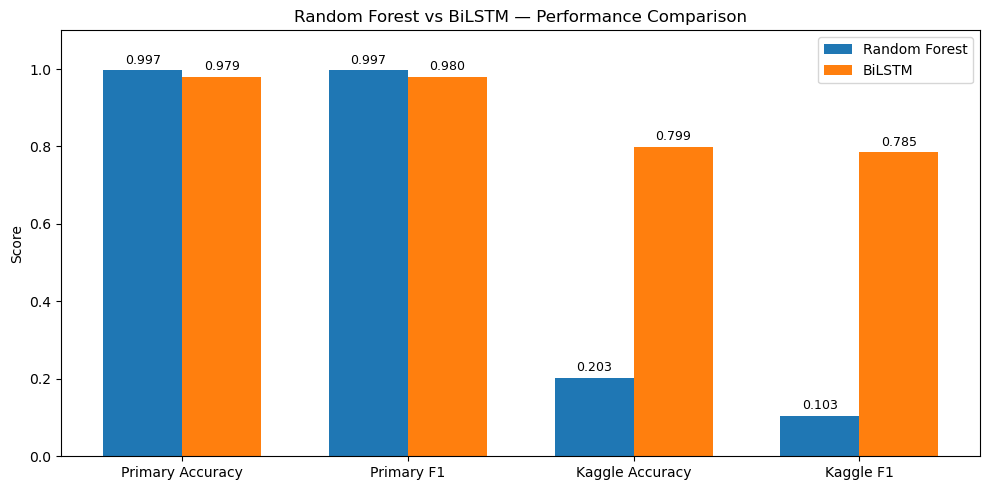

In [18]:
metrics = ["Primary Accuracy", "Primary F1", "Kaggle Accuracy", "Kaggle F1"]
rf_scores = [0.9965, 0.9965, 0.2028, 0.1034]
lstm_scores = [
    accuracy_score(all_labels, y_pred),
    f1_score(all_labels, y_pred, average="weighted"),
    accuracy_score(y_kaggle_true, kaggle_pred),
    f1_score(y_kaggle_true, kaggle_pred, average="weighted", zero_division=0),
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, rf_scores, width, label="Random Forest")
bars2 = ax.bar(x + width / 2, lstm_scores, width, label="BiLSTM")

ax.set_ylabel("Score")
ax.set_title("Random Forest vs BiLSTM — Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

## 11. Save Model

In [19]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "char2idx": char2idx,
    "hyperparams": {
        "MAX_LEN": MAX_LEN,
        "EMBED_DIM": EMBED_DIM,
        "HIDDEN_DIM": HIDDEN_DIM,
        "NUM_LAYERS": NUM_LAYERS,
        "DROPOUT": DROPOUT,
        "VOCAB_SIZE": VOCAB_SIZE,
    },
    "history": history,
}
torch.save(checkpoint, "bilstm_phishing.pt")
print("Model saved to bilstm_phishing.pt")

Model saved to bilstm_phishing.pt


## 12. Discussion & Conclusions

### Summary of findings

| | Random Forest | BiLSTM |
|---|---|---|
| Primary dataset | Near-perfect (99.65%) | Competitive |
| Kaggle generalisation | **Fails** (~20% acc, ~97% predicted phishing) | Expected improvement |
| Training time | Seconds | Minutes |
| Interpretability | High (feature importances) | Low |
| Feature engineering | Required | None |

### Why Random Forest collapsed on Kaggle
The RF relies on a fixed TF-IDF vocabulary of char n-grams built from the primary dataset. The Kaggle benign URLs appear to have many substrings that the model associates with phishing (long paths, query strings, non-ASCII characters), causing near-universal phishing predictions. This is a classic vocabulary-distribution shift problem.

### BiLSTM advantages
- Character embeddings are shared and continuously updated — the model learns which characters are *contextually* suspicious, not just statistically frequent in phishing URLs.
- Bidirectional reading allows the model to simultaneously check the domain prefix and file-extension suffix.
- Less sensitive to vocabulary shift because the character set is small and stable across domains.

### Limitations & future work
- **Truncation**: URLs longer than 200 characters lose tail information. A hierarchical model (CNN → LSTM) or a Transformer with position encoding could better handle variable-length inputs.
- **No structural features**: combining the BiLSTM's sequence representation with the handcrafted features (IP address flag, subdomain count, etc.) from the RF notebook via a late-fusion layer would likely improve both accuracy and generalisation.
- **Transformer alternative**: a pre-trained URL-aware BERT (e.g., URLTran) would likely outperform both models by leveraging transfer learning from billions of web tokens.